In [1]:
import numpy as np
import matplotlib.pyplot as plt 

# Datasets

## Generating a random dataset

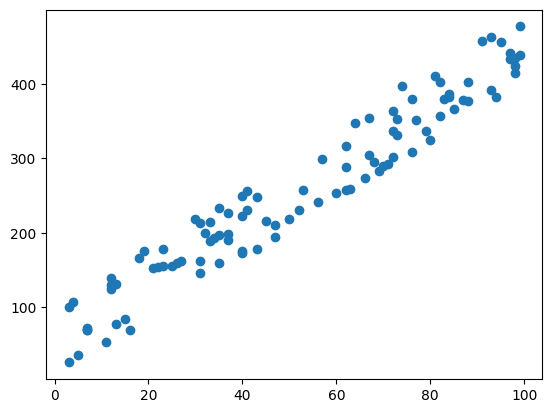

In [24]:
#np.random.seed(42)
train_X = []
train_y = []

for i in range(1, 101):

    A = np.random.randint(1, 100)
    train_X.append(A)
    train_y.append(A * 4 + 3 + np.random.randint(1, 100))

train_X = np.array(train_X).reshape(-1, 1)
train_y = np.array(train_y).reshape(-1, 1)

train_X_b = np.c_[np.ones((100, 1)), train_X] # Adding intercept (x0 = 1)


plt.scatter(train_X,train_y)
plt.show()

# Training

During the training, the model tries to minimize a cost function, which measures how far the predictions are from the true values

## Training with the normal equation

θ is the vector of values used by the model, it contains the bias term θ₀ and the weights θ₁ to θₙ, which show how important each input value is in the prediction.
</br> So X θ is the dot product of the value vector and the associated weight vector.
</br> We can use a closed-form solution to find the value of θ that minimizes the cost function:

- X θ ≈ y
- Xᵀ X θ = Xᵀ y 
- (Xᵀ X)⁻¹ (Xᵀ X) θ = (Xᵀ X)⁻¹ Xᵀ y
- θ = (Xᵀ X)⁻¹ Xᵀ y

In [67]:
theta_best = np.linalg.inv(train_X_b.T @ train_X_b) @ train_X_b.T @ train_y
theta_best

array([[60.13142135],
       [ 3.88490472]])

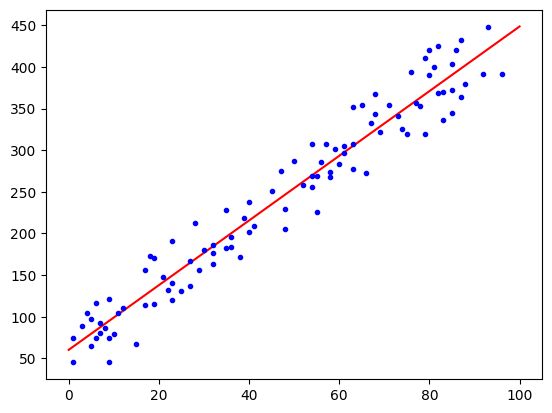

In [68]:
# Test
X_new = np.array([[0], [100]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b @ theta_best
y_predict

plt.plot(X_new, y_predict, "r-")
plt.plot(train_X, train_y, "b.")

plt.show()

We have a pretty good fit here ! </br>
Note that the normal equation works for any model that is linear in θ, but it can work for one that is non linear in x such as y = θ₀ + θ₁x + θ₂ sin(x)

## Training with the gradient descent

The idea is to tweak the parameters iteratively in order to minimize a cost function. <br>
We start with by giving a random value to θ (random initialization) and for every step we take, we try to minimize the loss function, until the algorithm converges to a minimum.

"Fortunately, the MSE cost function for a Linear Regression model happens to be a convex function" Aurelien Geron, Hands on ML

We can compute the gradient for a batch using the formula below.

![description](images/gradient_vector_of_cost_function.png)

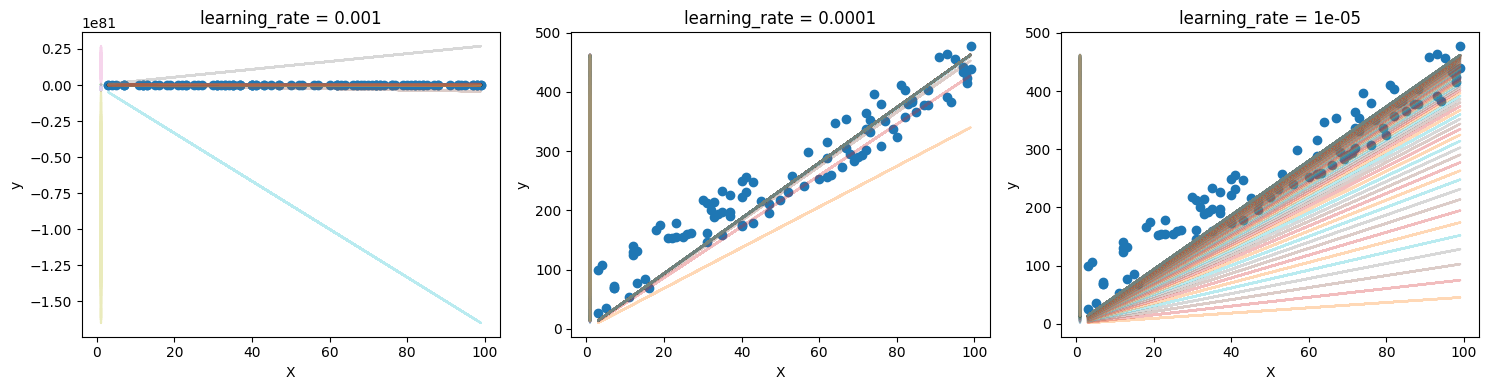

In [ ]:
# We try with 3 different learning rates

learning_rates = [0.001, 0.0001, 0.00001]
n_iterations = 100
m = len(train_X)

fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))
for ax, learning_rate in zip(axes, learning_rates):
    theta = np.random.randn(2, 1) # random initialization

    ax.scatter(train_X, train_y)

    for iteration in range(n_iterations):
        gradients = 2 / m * train_X_b.T @ (train_X_b @ theta - train_y)
        theta = theta - gradients * learning_rate

        y_predict = train_X_b @ theta
        ax.plot(train_X_b, y_predict, alpha=0.3)

    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.set_title(f"learning_rate = {learning_rate}")

plt.tight_layout()
plt.show()



This is a good visualization of the importance of having the good learning rate. 